# 04 - Centrality Analysis

This notebook ranks the stations of Israel's public-transport network by several centrality measures, and checks whether the different measures agree with each other. We compute degree and weighted degree (service volume), weighted PageRank on the directed trip graph (flow importance), approximate betweenness on the largest connected component (importance as a transfer / bridging node), and harmonic centrality (accessibility). We then compare the rankings with a Spearman correlation matrix, and above all we measure how noisy the sampled betweenness estimate really is, before anyone builds a "critical station" threshold on top of it.

**Research question.** Do the cheap local measures (degree, weighted degree, PageRank) pick out the same stations as the expensive global one (betweenness)? If they do, the cheap measures are a good proxy; if they don't, the network has stations with structural importance that carry little traffic.

**Input**
- `outputs/nb/02_graph_construction/` - the node table and the directed edge table produced by the `02_graph_construction` notebook (station attributes; `from_stop`, `to_stop`, trip frequency per segment).
- No raw GTFS file is needed. The file `stop_times.txt` (816 MB) is required only for an optional sanity check at the end of the notebook, and only if it already exists on disk.

**Output** (all under `outputs/nb/04_centrality_analysis/`)
- `tables/stop_metrics.csv` - one row per station with all the centrality measures.
- `tables/top_degree.csv`, `top_weighted_degree.csv`, `top_pagerank.csv`, `top_approx_betweenness.csv`, `top_approx_harmonic.csv` - top-N rankings.
- `tables/centrality_correlation_spearman.csv` - Spearman matrix between the measures.
- `tables/betweenness_stability.csv` - how much the betweenness ranking changes when only the random sample of source nodes changes.
- `figures/` - top-N bar charts for each measure, a heatmap of the correlations, scatter plots of degree against the other measures, a map of the top betweenness stations, and the seed-vs-seed stability scatter plot.

**A note on honesty up front.** The betweenness here is a sample-based approximation over *k* sources (default `K_BETWEENNESS = 300` sources drawn from about 30,000 nodes, so roughly 1% of the possible sources). The estimate is noisy, especially in the tail of the distribution, and any downstream "critical station" rule - say a p90 threshold on betweenness - inherits that noise. We quantify this instead of hiding it.

## 1. Environment setup

The next cell lets the notebook run both locally and in Google Colab. It finds the repository root by climbing up from the current directory looking for the GTFS data folder, and if it can't find it (meaning we're on a fresh Colab machine) it clones the repository. It also installs only missing packages - nothing is reinstalled if it's already available. Every cell below assumes `REPO`, `DATA`, and `OUT` exist.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Repo root: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר


## 2. Imports, output folders, and tunable constants

Every parameter that controls the run time is collected in this single cell, so a reviewer can shrink them without reading the rest of the notebook.

- `K_BETWEENNESS = 300` - the number of source nodes sampled at random for the approximate betweenness. Exact betweenness on this graph would need a BFS from each of the roughly 30,000 nodes (hours). With `k = 300` a run takes about 1-3 minutes.
- `RUN_STABILITY_CHECK` - runs the betweenness *one more time* with a different random seed, so we can measure how much the ranking depends on the sample. This roughly doubles the betweenness cost; you can set it to `False` if you're in a hurry, but the honesty argument in section 11 relies on it.
- `HARMONIC_SAMPLES = 300` - harmonic centrality is also estimated from sampled sources (each source costs one BFS). Set it to `None` for the exact computation, which is one BFS per node and takes tens of minutes.
- `TOP_N = 15` - the length of the ranking tables and bar charts.

This notebook writes only to its own stage folder, `outputs/nb/04_centrality_analysis`. It never touches `outputs/tables`, `outputs/figures`, or `outputs/rail`.

In [2]:
_ensure("networkx", "pandas", "numpy", "matplotlib")

import csv
import json
import pickle
import random
import time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt

# ---------------- tunable constants (runtime lives here) ----------------
K_BETWEENNESS = 300          # sampled sources for approximate betweenness
BETWEENNESS_SEED = 42        # seed of the main sample
BETWEENNESS_SEED_B = 7       # seed of the second sample (noise check only)
RUN_STABILITY_CHECK = True   # False -> skip the second betweenness run
HARMONIC_SAMPLES = 300       # None -> exact harmonic centrality (very slow)
TOP_N = 15                   # rows per ranking table / bars per chart
CRITICAL_QUANTILE = 0.90     # the p90 rule we stress-test in section 11

# ---------------- stage folders ----------------
STAGE = OUT / "04_centrality_analysis"
TABLES = STAGE / "tables"
FIGURES = STAGE / "figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
STAGE02 = OUT / "02_graph_construction"

print("stage folder :", STAGE)
print("reads stage  :", STAGE02)
print("networkx", nx.__version__, "| pandas", pd.__version__)

stage folder : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\04_centrality_analysis
reads stage  : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\02_graph_construction
networkx 3.4.2 | pandas 2.3.3


## 3. Hebrew labels in matplotlib

Station names in the Israeli GTFS feed are in Hebrew. matplotlib stores text in logical order and doesn't apply the Unicode bidirectional algorithm, so a Hebrew label is drawn left to right, meaning visually reversed. The patch below wraps `Text.set_text` and converts Hebrew strings to display order once, before anything is drawn. Latin text is returned unchanged, and the patch is idempotent so re-running the cell does no harm.

In [3]:
# Stop names are Hebrew. Matplotlib does not apply the Unicode bidi algorithm, so
# Hebrew labels render reversed. Patch it once, before drawing any figure.
_ensure("python-bidi")
import re
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext
from bidi.algorithm import get_display

_HEBREW_RE = re.compile(r"[\u0590-\u05FF]")

def fix_he(text):
    """Return display-ordered text. Non-Hebrew is returned untouched."""
    if not isinstance(text, str) or not _HEBREW_RE.search(text):
        return text
    return get_display(text)

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    if getattr(mtext.Text, "_bidi_patched", False):
        return
    _orig = mtext.Text.set_text
    def set_text(self, s):
        if isinstance(s, str) and getattr(self, "_bidi_display", None) == s:
            return _orig(self, s)
        fixed = fix_he(s)
        if isinstance(fixed, str):
            self._bidi_display = fixed
        return _orig(self, fixed)
    mtext.Text.set_text = set_text
    mtext.Text._bidi_patched = True

install_hebrew()

## 4. Loading the graph produced in notebook 02

This step doesn't rebuild the graph from raw GTFS - that's notebook 02's job. Here we read the node table (station attributes) and the directed edge table (one row per `from_stop -> to_stop` segment together with the number of trips using it), and rebuild the two `networkx` objects we need:

- `D`, a directed graph whose edge weight is the trip frequency on the segment. This is the object PageRank runs on, because direction matters for flow.
- `G`, the undirected projection whose edge weight is the sum of both directions. Degree, betweenness, and harmonic centrality run on it, because a passenger going between two neighboring stations isn't affected by the direction in which the edge was recorded.

The data loader is deliberately tolerant about file names and column names (`weight` vs `trip_frequency`, `source` vs `from_stop`, and so on), so it keeps working even if notebook 02 renames something. If the stage-02 folder is missing entirely, a clear, active error is raised instead of silently building an empty graph.

In [4]:
def _find_artifact(stage_dir, names, keyword):
    """Locate a stage artifact by exact name, then by keyword, under <stage>/tables or <stage>."""
    for name in names:
        for cand in (stage_dir / "tables" / name, stage_dir / name):
            if cand.exists():
                return cand
    hits = sorted(p for p in stage_dir.rglob("*.csv") if keyword in p.name.lower())
    return hits[0] if hits else None


def _pick_column(df, candidates):
    """Return the first column of df matching one of candidates (case-insensitive)."""
    lower = {str(c).lower(): c for c in df.columns}
    for cand in candidates:
        if cand in lower:
            return lower[cand]
    return None


if not STAGE02.exists():
    raise FileNotFoundError(
        f"{STAGE02} missing - run notebook 02_graph_construction first."
    )

edges_path = _find_artifact(
    STAGE02,
    ["edges.csv", "graph_edges.csv", "edges_directed.csv", "directed_edges.csv"],
    "edge",
)
nodes_path = _find_artifact(
    STAGE02, ["nodes.csv", "graph_nodes.csv", "stops_nodes.csv"], "node"
)
if edges_path is None:
    raise FileNotFoundError(
        f"No edge table found under {STAGE02} - run notebook 02_graph_construction first."
    )
print("edges from:", edges_path)
print("nodes from:", nodes_path)

edges_df = pd.read_csv(edges_path, dtype=str, encoding="utf-8-sig")
src_col = _pick_column(edges_df, ["from_stop", "from_stop_id", "source", "from", "u"])
dst_col = _pick_column(edges_df, ["to_stop", "to_stop_id", "target", "to", "v"])
wgt_col = _pick_column(
    edges_df, ["trip_frequency", "weight", "frequency", "trips", "n_trips", "count"]
)
if src_col is None or dst_col is None:
    raise ValueError(f"Cannot identify endpoint columns in {edges_path}: {list(edges_df.columns)}")
weights = (
    pd.to_numeric(edges_df[wgt_col], errors="coerce").fillna(1.0)
    if wgt_col is not None
    else pd.Series(1.0, index=edges_df.index)
)

# Directed trip graph: weight = number of trips using the segment.
D = nx.DiGraph()
for u, v, w in zip(edges_df[src_col], edges_df[dst_col], weights):
    if u == v or pd.isna(u) or pd.isna(v):
        continue
    if D.has_edge(u, v):
        D[u][v]["weight"] += float(w)
    else:
        D.add_edge(u, v, weight=float(w))

# Undirected projection: weight = sum of both directions.
G = nx.Graph()
for u, v, data in D.edges(data=True):
    if G.has_edge(u, v):
        G[u][v]["weight"] += data["weight"]
    else:
        G.add_edge(u, v, weight=data["weight"])

# Station attributes (name, coordinates, region, metro) if notebook 02 saved them.
ATTR = {}
VISIT_COL = None
if nodes_path is not None:
    nodes_df = pd.read_csv(nodes_path, dtype=str, encoding="utf-8-sig")
    id_col = _pick_column(nodes_df, ["stop_id", "node", "id"])
    name_col = _pick_column(nodes_df, ["stop_name", "name"])
    lat_col = _pick_column(nodes_df, ["lat", "stop_lat", "latitude"])
    lon_col = _pick_column(nodes_df, ["lon", "stop_lon", "longitude"])
    reg_col = _pick_column(nodes_df, ["region", "district"])
    met_col = _pick_column(nodes_df, ["metro", "metropolitan"])
    VISIT_COL = _pick_column(
        nodes_df,
        ["stop_use_count", "visits", "stop_visits", "visit_count", "n_visits"],
    )
    if id_col is not None:
        for row in nodes_df.itertuples(index=False):
            rec = dict(zip(nodes_df.columns, row))
            sid = rec[id_col]
            ATTR[sid] = {
                "stop_name": rec.get(name_col, "") if name_col else "",
                "lat": pd.to_numeric(rec.get(lat_col), errors="coerce") if lat_col else np.nan,
                "lon": pd.to_numeric(rec.get(lon_col), errors="coerce") if lon_col else np.nan,
                "region": rec.get(reg_col, "") if reg_col else "",
                "metro": rec.get(met_col, "") if met_col else "",
                "stop_use_count": pd.to_numeric(rec.get(VISIT_COL), errors="coerce")
                if VISIT_COL
                else np.nan,
            }
        # Keep stations that stage 02 listed even if they ended up with no segment.
        G.add_nodes_from(ATTR.keys())
        D.add_nodes_from(ATTR.keys())

print(f"directed graph  : {D.number_of_nodes():,} nodes, {D.number_of_edges():,} edges")
print(f"undirected graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
print(f"attributes for  : {len(ATTR):,} stations"
      + (f" (visit counts in column '{VISIT_COL}')" if VISIT_COL else " (no visit-count column)"))

edges from: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\02_graph_construction\tables\edges.csv
nodes from: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\02_graph_construction\tables\nodes.csv


directed graph  : 30,463 nodes, 51,999 edges
undirected graph: 30,463 nodes, 51,772 edges
attributes for  : 30,463 stations (visit counts in column 'stop_use_count')


## 5. Sanity check and the largest connected component

Two of the global centrality measures - betweenness and harmonic centrality - are only meaningful between nodes that can actually reach each other, so both are computed on the largest connected component (LCC) of `G`. Stations outside the LCC get a score of 0, which is the honest value: they aren't reachable from the body of the network, so they aren't on any shortest path within it. We print the size of the LCC so the reader knows how much of the network the global measures actually cover.

In [5]:
components = sorted(nx.connected_components(G), key=len, reverse=True)
Gc = G.subgraph(components[0]).copy()

n_nodes = G.number_of_nodes()
print(f"connected components : {len(components):,}")
print(f"largest component    : {Gc.number_of_nodes():,} nodes "
      f"({Gc.number_of_nodes() / n_nodes:.1%} of the network), "
      f"{Gc.number_of_edges():,} edges")
print(f"isolated / off-LCC   : {n_nodes - Gc.number_of_nodes():,} stations")
print(f"average degree       : {2 * G.number_of_edges() / n_nodes:.2f}")
print(f"betweenness sampling : k = {min(K_BETWEENNESS, Gc.number_of_nodes()):,} sources "
      f"= {min(K_BETWEENNESS, Gc.number_of_nodes()) / Gc.number_of_nodes():.2%} of the LCC")

connected components : 12


largest component    : 30,237 nodes (99.3% of the network), 51,523 edges
isolated / off-LCC   : 226 stations
average degree       : 3.40
betweenness sampling : k = 300 sources = 0.99% of the LCC


## 6. Degree and weighted degree

The cheapest measures, and the baseline everything else is compared against.

- `degree` - how many distinct neighboring stations the station connects to. This counts *topological* branching: a station serving many different traffic corridors gets a high score.
- `degree_centrality` - the same number divided by `n - 1`, networkx's normalization.
- `weighted_degree` - the sum of trip frequencies over all adjacent segments, that is the total daily service volume passing through the station. This counts *traffic*, not branching: a station on a single corridor served by an especially frequent bus line gets a high score.
- `in_degree`, `out_degree`, `in_weight`, `out_weight` - the directed versions, taken from `D`. For a station in the middle of a two-way corridor these values are close to symmetric; a large asymmetry usually marks a terminal station or a one-way loop.

All of these are dictionary queries on the graph and cost next to nothing.

In [6]:
degree = dict(G.degree())
weighted_degree = dict(G.degree(weight="weight"))
in_degree = dict(D.in_degree())
out_degree = dict(D.out_degree())
in_weight = dict(D.in_degree(weight="weight"))
out_weight = dict(D.out_degree(weight="weight"))

print("degree      : max", max(degree.values()), "| mean", round(np.mean(list(degree.values())), 2))
print("weighted deg: max", int(max(weighted_degree.values())),
      "| mean", round(np.mean(list(weighted_degree.values())), 1))

degree      : max 62 | mean 3.4
weighted deg: max 21396 | mean 1003.9


## 7. Weighted PageRank on the directed graph

PageRank models a passenger doing a random walk along the network, who with probability `1 - alpha = 0.15` teleports to a random station. A station gets a high score when many *frequently served* segments lead into it from stations that are themselves important, so PageRank is a flow-weighted notion of importance and not just a local count.

We run it on the **directed** graph `D` with `weight="weight"` (trip frequency), so one-way segments and asymmetric service are taken into account. Dangling nodes - terminal stations with no outgoing segment - get their rank redistributed uniformly, which is the standard treatment.

networkx's default `pagerank` uses SciPy. If SciPy isn't installed, we fall back to a pure-Python power iteration (the same implementation used in the project's script pipeline), so the notebook never fails in a minimal environment. Either path costs a few seconds.

In [7]:
def weighted_pagerank(graph, weight="weight", alpha=0.85, max_iter=100, tol=1.0e-6):
    """Weighted PageRank via power iteration, without requiring SciPy."""
    nodes = list(graph.nodes)
    n = len(nodes)
    if n == 0:
        return {}
    rank = {node: 1.0 / n for node in nodes}
    out_w = {
        node: sum(data.get(weight, 1.0) for _, _, data in graph.out_edges(node, data=True))
        for node in nodes
    }
    for _ in range(max_iter):
        previous = rank
        dangling = sum(previous[node] for node in nodes if out_w[node] == 0)
        base = (1.0 - alpha) / n + alpha * dangling / n
        rank = {node: base for node in nodes}
        for source in nodes:
            total = out_w[source]
            if total == 0:
                continue
            src_rank = previous[source]
            for _, target, data in graph.out_edges(source, data=True):
                rank[target] += alpha * src_rank * data.get(weight, 1.0) / total
        if sum(abs(rank[node] - previous[node]) for node in nodes) < n * tol:
            return rank
    return rank


t0 = time.time()
try:
    pagerank = nx.pagerank(D, alpha=0.85, weight="weight")
    engine = "networkx (SciPy)"
except Exception as exc:  # SciPy missing or convergence failure
    print("networkx pagerank unavailable ->", exc, "| falling back to pure Python")
    pagerank = weighted_pagerank(D, weight="weight")
    engine = "pure Python power iteration"

print(f"PageRank via {engine} in {time.time() - t0:.1f}s; "
      f"sum = {sum(pagerank.values()):.4f} (should be ~1.0)")

PageRank via networkx (SciPy) in 0.2s; sum = 1.0000 (should be ~1.0)


## 8. Approximate betweenness centrality

Betweenness counts the fraction of shortest paths that pass through a station. This is the measure that actually captures *bridging*: a station with only two neighbors can still have enormous betweenness if it's the only way from one part of the country to another. That's exactly the property a "critical stations" analysis cares about.

It's also the most expensive measure by a wide margin. Exact Brandes is `O(n * m)`, and for about 30,000 nodes and about 40,000 edges that means a BFS from every node - hours of computation. So we use networkx's sampled estimate: pick `k` random source nodes, run Brandes accumulation from those sources only, and rescale accordingly.

**Read this before using the numbers.** With `K_BETWEENNESS = 300` we sample about 1% of the possible sources. The estimate is unbiased in expectation but has real variance: the top of the ranking (nationwide bridges, which sit on shortest paths from almost *every* source) is stable, while the middle and the tail move noticeably between samples. Section 11 measures by how much. Betweenness is computed on the LCC and unweighted - "shortest" means the fewest segments, not the fastest or most frequent - the same convention used everywhere else in this project.

In [8]:
k_eff = min(K_BETWEENNESS, Gc.number_of_nodes())
t0 = time.time()
betweenness = nx.betweenness_centrality(
    Gc, k=k_eff, seed=BETWEENNESS_SEED, normalized=True, weight=None
)
print(f"approximate betweenness: k={k_eff}, seed={BETWEENNESS_SEED}, "
      f"{time.time() - t0:.1f}s")
nonzero = sum(1 for v in betweenness.values() if v > 0)
print(f"stations with a non-zero estimate: {nonzero:,} of {len(betweenness):,} "
      f"({nonzero / len(betweenness):.1%}) - the rest were simply never on a sampled path")

approximate betweenness: k=300, seed=42, 24.0s
stations with a non-zero estimate: 27,552 of 30,237 (91.1%) - the rest were simply never on a sampled path


## 9. Harmonic centrality (sampled) on the largest connected component

Harmonic centrality sums `1 / d(u, v)` over all other stations `v`. Unlike closeness it's well defined even when some pairs are unreachable, and it answers a different question from betweenness: not "how many paths go through me" but "how close am I to everyone else", that is accessibility rather than bridging.

The exact computation is again one BFS per node. So we use the same sampling trick as the project's script pipeline: draw `HARMONIC_SAMPLES` random sources, run a BFS from each of them, accumulate `1 / d` to every destination we reach, and rescale by a factor of `n_nodes / n_samples`. Since the graph is undirected, distance is symmetric, so sampling sources is a valid unbiased estimate of the sum over destinations. Set `HARMONIC_SAMPLES = None` to compute it exactly (slow). Like betweenness, the sampled version is noisy too, but harmonic centrality is a smooth quantity without a heavy tail, so it behaves far better under sampling than betweenness does.

In [9]:
def approximate_harmonic_centrality(graph, samples, seed):
    """Estimate harmonic centrality from `samples` random BFS sources, rescaled to n."""
    if graph.number_of_nodes() == 0 or not samples:
        return {}
    rng = random.Random(seed)
    nodes = list(graph.nodes)
    sources = rng.sample(nodes, min(samples, len(nodes)))
    scores = defaultdict(float)
    for source in sources:
        lengths = nx.single_source_shortest_path_length(graph, source)
        for target, distance in lengths.items():
            if target == source or distance == 0:
                continue
            scores[target] += 1.0 / distance
    scale = graph.number_of_nodes() / len(sources)
    return {node: value * scale for node, value in scores.items()}


t0 = time.time()
if HARMONIC_SAMPLES is None:
    harmonic = nx.harmonic_centrality(Gc)
    harmonic_mode = "exact"
else:
    harmonic = approximate_harmonic_centrality(Gc, HARMONIC_SAMPLES, BETWEENNESS_SEED)
    harmonic_mode = f"sampled ({HARMONIC_SAMPLES} sources)"
print(f"harmonic centrality [{harmonic_mode}] in {time.time() - t0:.1f}s "
      f"for {len(harmonic):,} stations")

harmonic centrality [sampled (300 sources)] in 5.6s for 30,237 stations


## 10. Assembling `stop_metrics.csv` and the top-N tables

Everything computed so far is keyed by `stop_id`; this cell joins it all into one tidy table together with the station attributes (name, coordinates, region, metropolitan area) and writes it to disk. Stations outside the LCC get `0.0` for betweenness and harmonic centrality, as explained in section 5.

We also write one top-`TOP_N` table per measure. Keeping them as separate files makes it clear which ranking each claim came from.

In [10]:
default_attr = {"stop_name": "", "lat": np.nan, "lon": np.nan,
                "region": "", "metro": "", "stop_use_count": np.nan}

rows = []
for stop_id in G.nodes:
    a = ATTR.get(stop_id, default_attr)
    deg = degree.get(stop_id, 0)
    rows.append({
        "stop_id": stop_id,
        "stop_name": a.get("stop_name", ""),
        "region": a.get("region", ""),
        "metro": a.get("metro", ""),
        "lat": a.get("lat", np.nan),
        "lon": a.get("lon", np.nan),
        "stop_use_count": a.get("stop_use_count", np.nan),
        "degree": deg,
        "degree_centrality": deg / (n_nodes - 1) if n_nodes > 1 else 0.0,
        "weighted_degree": weighted_degree.get(stop_id, 0.0),
        "in_degree": in_degree.get(stop_id, 0),
        "out_degree": out_degree.get(stop_id, 0),
        "in_weight": in_weight.get(stop_id, 0.0),
        "out_weight": out_weight.get(stop_id, 0.0),
        "pagerank": pagerank.get(stop_id, 0.0),
        "approx_betweenness": betweenness.get(stop_id, 0.0),
        "approx_harmonic": harmonic.get(stop_id, 0.0),
        "in_largest_component": stop_id in Gc,
    })

metrics = pd.DataFrame(rows).sort_values("weighted_degree", ascending=False)
metrics["label"] = metrics["stop_name"].fillna("").astype(str).str.strip()
metrics["label"] = metrics["label"].where(metrics["label"] != "", metrics["stop_id"])

metrics.drop(columns=["label"]).to_csv(
    TABLES / "stop_metrics.csv", index=False, encoding="utf-8-sig"
)

RANKINGS = {
    "top_degree.csv": "degree",
    "top_weighted_degree.csv": "weighted_degree",
    "top_pagerank.csv": "pagerank",
    "top_approx_betweenness.csv": "approx_betweenness",
    "top_approx_harmonic.csv": "approx_harmonic",
}
for filename, column in RANKINGS.items():
    (metrics.drop(columns=["label"])
            .sort_values(column, ascending=False)
            .head(TOP_N)
            .to_csv(TABLES / filename, index=False, encoding="utf-8-sig"))

print(f"stop_metrics.csv written: {len(metrics):,} rows -> {TABLES}")
display(metrics.nlargest(10, "approx_betweenness")[
    ["stop_name", "stop_id", "region", "degree", "weighted_degree",
     "pagerank", "approx_betweenness"]
])

stop_metrics.csv written: 30,463 rows -> C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\04_centrality_analysis\tables


,stop_name,stop_id,region,degree,weighted_degree,pagerank,approx_betweenness
266,ת.התרעננות/דור אלון מגל 6,17303,Center,16,220.0,0.000010,0.112460
229,מחלף חמד,41133,Jerusalem,62,10454.0,0.000125,0.087536
1315,מחלף קמה לצפון,27689,South,24,1304.0,0.000092,0.071648
354,דרך האר''י/ כביש 375,7444,Jerusalem,29,5272.0,0.000056,0.069171
1792,מחלף חמד,41132,Jerusalem,44,10540.0,0.000399,0.066713
964,שדרות בית הלל/כניסה לעיר,7562,Center,29,3870.0,0.000082,0.065786
556,רבי יהודה הנשיא/כניסה לעיר,23418,Center,24,1374.0,0.000047,0.056599
5272,מחלף קסם,748,Center,19,1534.0,0.000059,0.047273
1305,תחנת התרעננות/פונדק בית קמה,29243,South,19,520.0,0.000027,0.046289
5918,צומת חנניה צומת שבע,18876,North,13,636.0,0.000034,0.043864


## 11. How noisy is the sampled betweenness? (the honesty section)

A ranking is only useful if it's reproducible. Here we re-run the *same* estimate with a different random seed - nothing in the network changes, only which 300 sources were drawn - and compare the two results in three ways:

1. **Spearman correlation** between the two score vectors. A high overall correlation is expected and doesn't prove much, because most stations get a score of about 0 in both runs.
2. **Top-50 overlap.** How many of the 50 top stations in run A also appear in the top 50 of run B. This is the number that matters for the question "which stations are critical".
3. **Agreement on a p90 threshold.** A common downstream rule is "a station is critical if its betweenness is above the 90th percentile". We build this flag from each run and report the Jaccard overlap between the two flag sets. Any instability found here is inherited by every claim built on such a threshold.

This cell costs one extra betweenness run (about 1-3 minutes). Set `RUN_STABILITY_CHECK = False` to skip it.

second betweenness run (seed=7) in 24.1s


,value
k_samples,300.000000
lcc_nodes,30237.000000
sampling_fraction,0.009922
spearman_all_nodes,0.956400
spearman_both_positive,0.941600
top10_overlap,0.900000
top50_overlap,0.840000
p90_flag_jaccard,0.529600
p90_flagged_seed_a,3024.000000
p90_flagged_seed_b,3024.000000


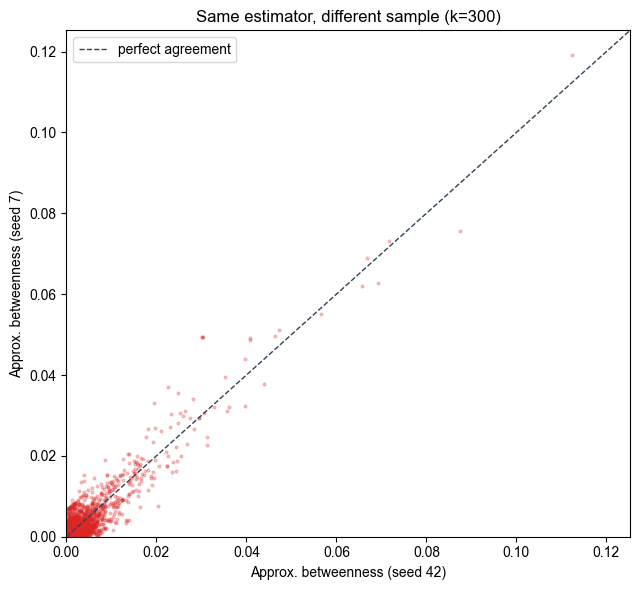

In [11]:
stability = None
if RUN_STABILITY_CHECK:
    t0 = time.time()
    betweenness_b = nx.betweenness_centrality(
        Gc, k=k_eff, seed=BETWEENNESS_SEED_B, normalized=True, weight=None
    )
    print(f"second betweenness run (seed={BETWEENNESS_SEED_B}) in {time.time() - t0:.1f}s")

    joint = pd.DataFrame({
        "seed_a": pd.Series(betweenness),
        "seed_b": pd.Series(betweenness_b),
    }).fillna(0.0)

    rho_all = joint["seed_a"].corr(joint["seed_b"], method="spearman")
    both_positive = joint[(joint["seed_a"] > 0) & (joint["seed_b"] > 0)]
    rho_pos = both_positive["seed_a"].corr(both_positive["seed_b"], method="spearman")

    top_a = set(joint.nlargest(50, "seed_a").index)
    top_b = set(joint.nlargest(50, "seed_b").index)
    overlap50 = len(top_a & top_b) / 50
    top_a10 = set(joint.nlargest(10, "seed_a").index)
    top_b10 = set(joint.nlargest(10, "seed_b").index)
    overlap10 = len(top_a10 & top_b10) / 10

    thr_a = joint["seed_a"].quantile(CRITICAL_QUANTILE)
    thr_b = joint["seed_b"].quantile(CRITICAL_QUANTILE)
    flag_a = joint["seed_a"] > thr_a
    flag_b = joint["seed_b"] > thr_b
    union = int((flag_a | flag_b).sum())
    jaccard = int((flag_a & flag_b).sum()) / union if union else float("nan")

    stability = pd.DataFrame([{
        "k_samples": k_eff,
        "lcc_nodes": Gc.number_of_nodes(),
        "sampling_fraction": k_eff / Gc.number_of_nodes(),
        "spearman_all_nodes": round(float(rho_all), 4),
        "spearman_both_positive": round(float(rho_pos), 4),
        "top10_overlap": overlap10,
        "top50_overlap": overlap50,
        "p90_flag_jaccard": round(float(jaccard), 4),
        "p90_flagged_seed_a": int(flag_a.sum()),
        "p90_flagged_seed_b": int(flag_b.sum()),
    }])
    stability.to_csv(TABLES / "betweenness_stability.csv", index=False, encoding="utf-8-sig")
    display(stability.T.rename(columns={0: "value"}))

    fig, ax = plt.subplots(figsize=(6.5, 6))
    ax.scatter(joint["seed_a"], joint["seed_b"], s=4, alpha=0.25, color="#dc2626")
    lim = max(joint["seed_a"].max(), joint["seed_b"].max()) * 1.05
    ax.plot([0, lim], [0, lim], color="#334155", lw=1, ls="--", label="perfect agreement")
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel(f"Approx. betweenness (seed {BETWEENNESS_SEED})")
    ax.set_ylabel(f"Approx. betweenness (seed {BETWEENNESS_SEED_B})")
    ax.set_title(f"Same estimator, different sample (k={k_eff})")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES / "betweenness_seed_stability.png", dpi=150)
    plt.show()
else:
    print("RUN_STABILITY_CHECK is False - skipping the betweenness noise measurement.")

## 12. Do the measures agree? The Spearman correlation matrix

Spearman correlation (rank correlation) is the right tool here because all of these distributions are heavy-tailed: Pearson would be dominated by the handful of huge stations. What we want to know is whether the measures produce the same *order*.

Some interpretation to keep in mind while reading the matrix:
- `degree` and `weighted_degree` are strongly correlated but not the same thing - one is branching, the other is traffic.
- `pagerank` is largely a smoothed version of weighted in-degree, so a high correlation with `weighted_degree` is expected and *not* an independent finding.
- The interesting cell is `approx_betweenness` against the local measures. A moderate rather than high correlation is the substantive result: it means bridging stations aren't simply the busiest stations. Keep in mind that the betweenness column is the noisy sampled estimate, so its correlations are attenuated - the true correlation with exact betweenness would be somewhat higher.

,degree,weighted_degree,pagerank,approx_betweenness,approx_harmonic
degree,1.0000,0.4681,0.4877,0.5139,0.4434
weighted_degree,0.4681,1.0000,0.6084,0.1868,0.3630
pagerank,0.4877,0.6084,1.0000,0.3220,0.0990
approx_betweenness,0.5139,0.1868,0.3220,1.0000,0.2772
approx_harmonic,0.4434,0.3630,0.0990,0.2772,1.0000


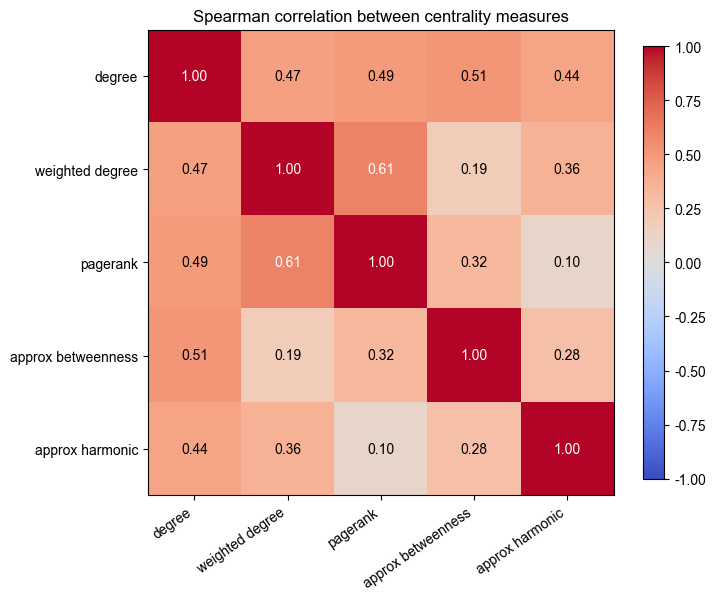

In [12]:
CORR_COLS = ["degree", "weighted_degree", "pagerank", "approx_betweenness", "approx_harmonic"]
corr = metrics[CORR_COLS].astype(float).corr(method="spearman").round(4)
corr.to_csv(TABLES / "centrality_correlation_spearman.csv", encoding="utf-8-sig")
display(corr)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(CORR_COLS)))
ax.set_xticklabels([c.replace("_", " ") for c in CORR_COLS], rotation=35, ha="right")
ax.set_yticks(range(len(CORR_COLS)))
ax.set_yticklabels([c.replace("_", " ") for c in CORR_COLS])
for i in range(len(CORR_COLS)):
    for j in range(len(CORR_COLS)):
        value = corr.values[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center",
                color="white" if abs(value) > 0.6 else "black", fontsize=10)
ax.set_title("Spearman correlation between centrality measures")
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
fig.savefig(FIGURES / "centrality_correlation_heatmap.png", dpi=150)
plt.show()

## 13. The top stations for each measure

One horizontal bar chart per measure, showing the `TOP_N` highest-scoring stations with their Hebrew names (rendered through the bidi patch from section 3; where a name is missing we fall back to the raw `stop_id`). The bars are drawn at explicit y positions rather than by category label, so two different stations with the same name don't merge into one bar - a real danger here, since names like the same street in different cities recur throughout the feed.

Comparing the four charts is the point: if the same stations dominate every chart, the measures are redundant; and if the betweenness chart lists stations that appear nowhere else, then the network has structural bottlenecks that traffic volume alone would miss.

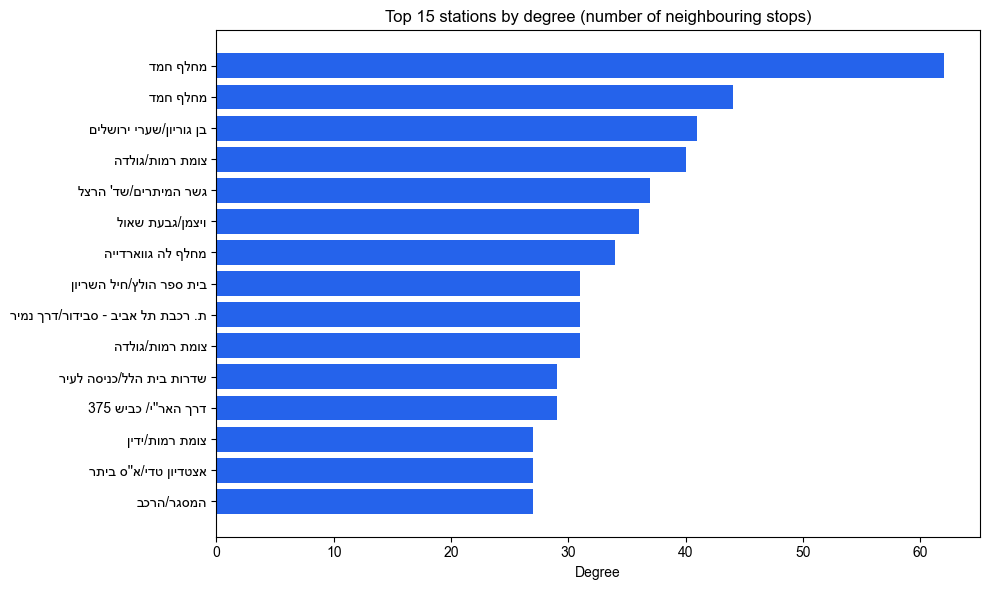

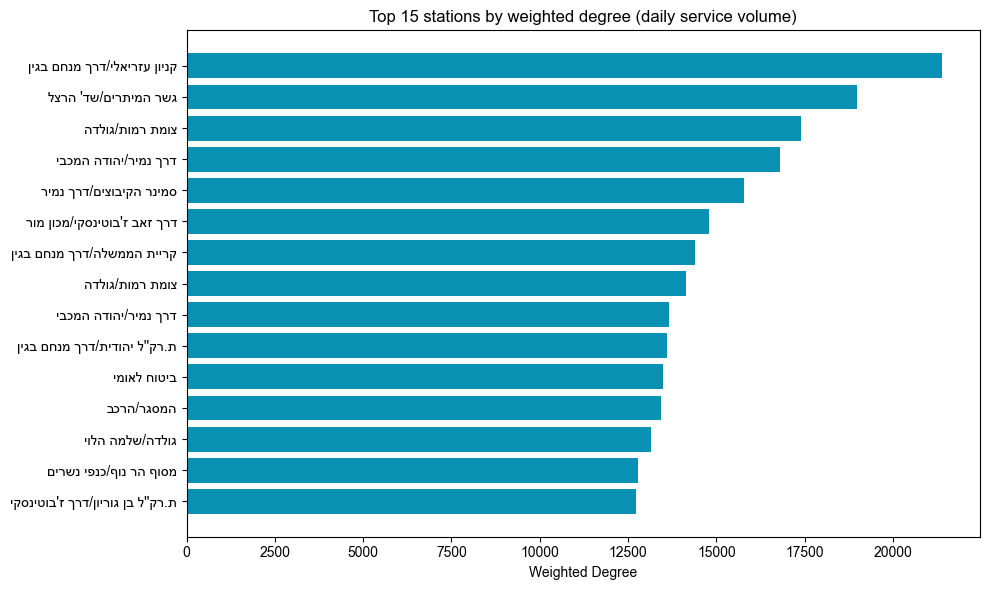

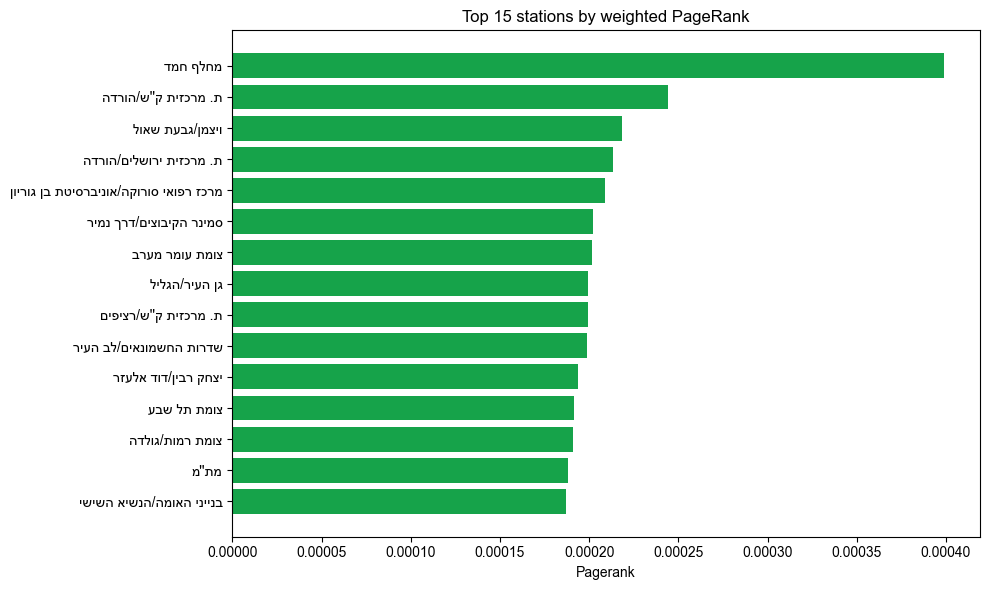

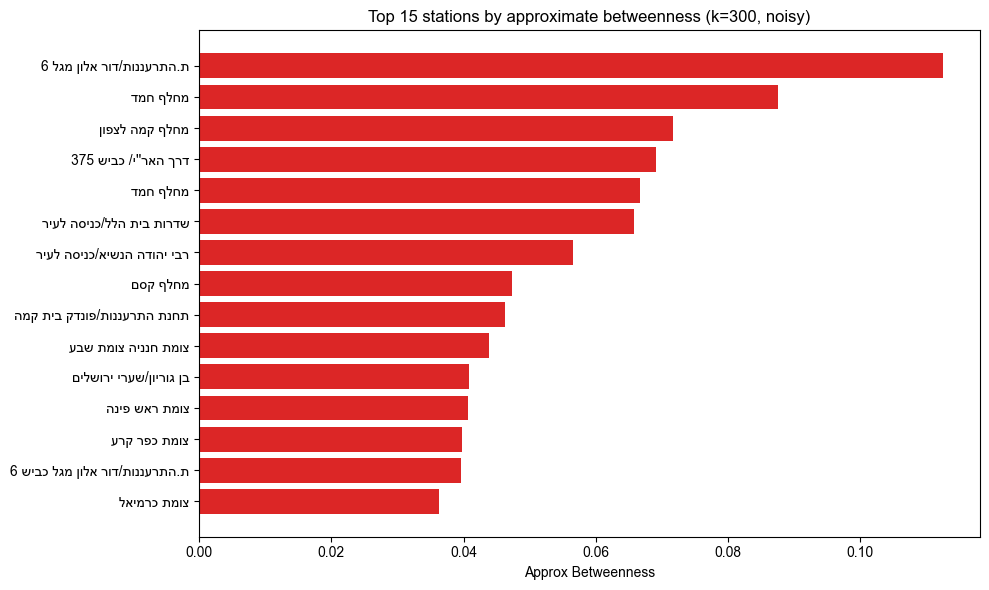

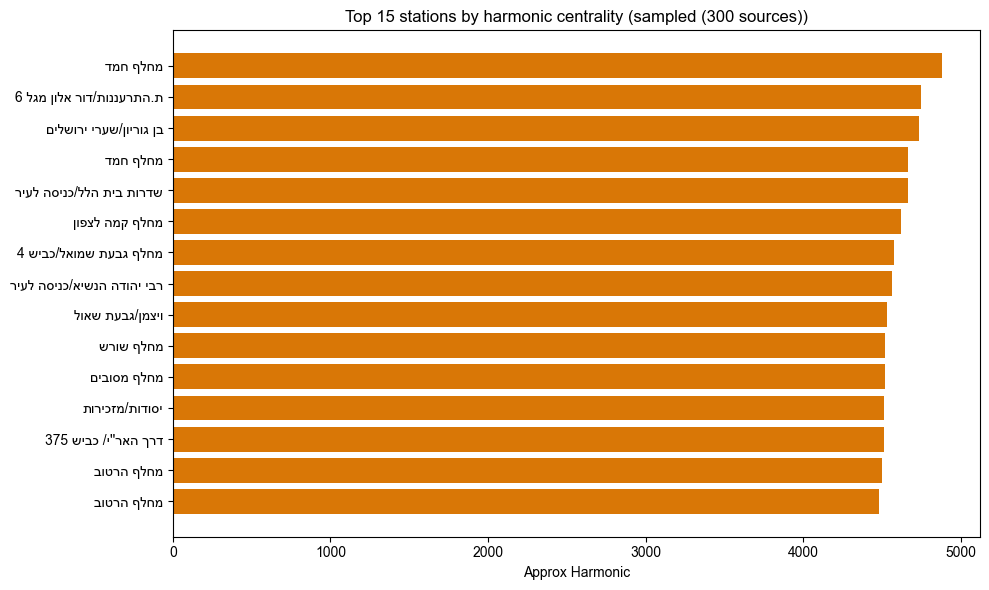

In [13]:
def plot_top(df, column, title, color, filename, n=TOP_N):
    top = df.nlargest(n, column)[["label", column]].copy().sort_values(column)
    y = np.arange(len(top))
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(y, top[column].astype(float).values, color=color)
    ax.set_yticks(y)
    ax.set_yticklabels(top["label"].astype(str).values)
    ax.set_xlabel(column.replace("_", " ").title())
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(FIGURES / filename, dpi=150)
    plt.show()


plot_top(metrics, "degree",
         f"Top {TOP_N} stations by degree (number of neighbouring stops)",
         "#2563eb", "top_degree.png")
plot_top(metrics, "weighted_degree",
         f"Top {TOP_N} stations by weighted degree (daily service volume)",
         "#0891b2", "top_weighted_degree.png")
plot_top(metrics, "pagerank",
         f"Top {TOP_N} stations by weighted PageRank",
         "#16a34a", "top_pagerank.png")
plot_top(metrics, "approx_betweenness",
         f"Top {TOP_N} stations by approximate betweenness (k={k_eff}, noisy)",
         "#dc2626", "top_approx_betweenness.png")
plot_top(metrics, "approx_harmonic",
         f"Top {TOP_N} stations by harmonic centrality ({harmonic_mode})",
         "#d97706", "top_approx_harmonic.png")

## 14. Where the measures disagree: scatter plots and a map

The correlation matrix gives one number per pair; these plots show the shape behind it.

- *Degree vs betweenness*: look for points low on the x axis and high on the y axis. These are the stations with low connectivity and high bridging - the ones a resilience analysis should worry about, and the ones a degree-based ranking would miss entirely.
- *Degree vs PageRank*: expected to be much tighter, since PageRank is essentially flow-weighted degree.
- The map draws all stations in a faint shade and highlights the 50 stations with the highest betweenness, colored by score. If these points line up along the Tel Aviv - Jerusalem - Haifa corridors rather than scattering, the estimate is picking up real nationwide structure and not just sampling noise - a useful qualitative check for section 11.

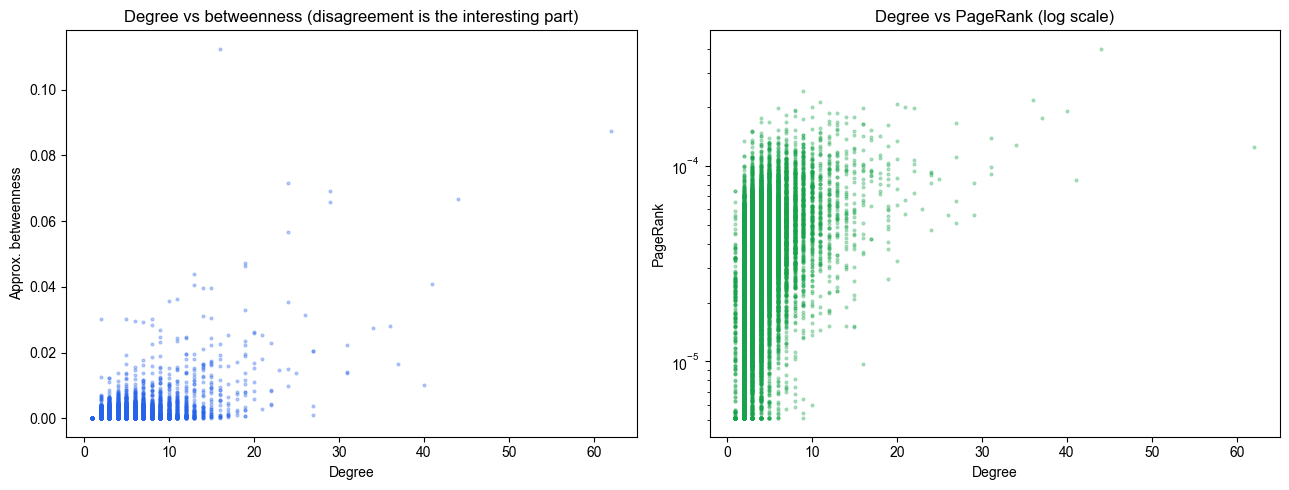

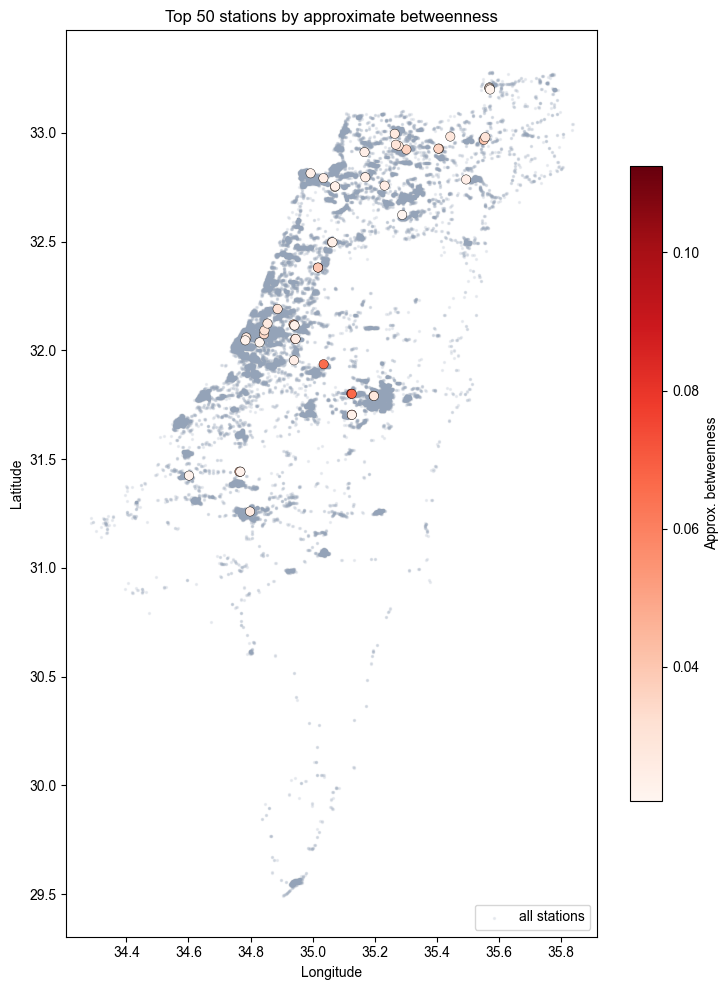

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(metrics["degree"], metrics["approx_betweenness"],
                s=4, alpha=0.3, color="#2563eb")
axes[0].set_xlabel("Degree")
axes[0].set_ylabel("Approx. betweenness")
axes[0].set_title("Degree vs betweenness (disagreement is the interesting part)")
axes[1].scatter(metrics["degree"], metrics["pagerank"],
                s=4, alpha=0.3, color="#16a34a")
axes[1].set_xlabel("Degree")
axes[1].set_ylabel("PageRank")
axes[1].set_yscale("log")
axes[1].set_title("Degree vs PageRank (log scale)")
fig.tight_layout()
fig.savefig(FIGURES / "centrality_scatter.png", dpi=150)
plt.show()

geo = metrics.dropna(subset=["lat", "lon"]).copy()
if len(geo):
    top_geo = geo.nlargest(50, "approx_betweenness")
    fig, ax = plt.subplots(figsize=(7.5, 10))
    ax.scatter(geo["lon"], geo["lat"], s=2, alpha=0.15, color="#94a3b8", label="all stations")
    sc = ax.scatter(top_geo["lon"], top_geo["lat"], s=45,
                    c=top_geo["approx_betweenness"], cmap="Reds",
                    edgecolors="black", linewidths=0.3, zorder=5)
    fig.colorbar(sc, ax=ax, label="Approx. betweenness", shrink=0.7)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Top 50 stations by approximate betweenness")
    ax.legend(loc="lower right")
    fig.tight_layout()
    fig.savefig(FIGURES / "betweenness_map.png", dpi=150)
    plt.show()
else:
    print("No coordinates available in the stage-02 node table - skipping the map.")

## 15. Weighted degree vs number of station visits - a tautology, not a finding

It's tempting to report "weighted degree correlates about 0.99 with the number of times a trip stops at the station, so busy stations are central". That correlation is real but it's **true by construction and carries no information**.

Both quantities are built from the same rows of `stop_times.txt`. Every time a trip stops at station `s` in the middle of its route it contributes exactly one incoming segment and one outgoing segment, so

```
weighted_degree(s) = in_weight(s) + out_weight(s) ~= 2 * visits(s)
```

with deviations only at the ends of a trip (a terminal station contributes one side, not two) and at consecutive duplicate station entries, which the graph builder drops. So the near-1 correlation is a restatement of the definition, roughly `y ~= 2x`, and can't serve as evidence of anything about the network.

The cell below verifies the identity `weighted_degree == in_weight + out_weight` exactly, and reports the correlation with the visit count *only* if stage 02 happened to keep a visit-count column (or if the 816 MB `stop_times.txt` file is already on disk - we never download it just for this check). Either way, the number is printed as a sanity check, not as a result.

In [15]:
# 1) Exact identity: undirected weighted degree = in_weight + out_weight.
identity_gap = (metrics["weighted_degree"]
                - (metrics["in_weight"] + metrics["out_weight"])).abs().max()
print(f"max |weighted_degree - (in_weight + out_weight)| = {identity_gap:.6f} "
      "(0 means the two are the same quantity)")

# 2) Visit counts, only if they are already available - no 816 MB download here.
visits = metrics["stop_use_count"]
if visits.notna().sum() == 0:
    stop_times_path = DATA / "stop_times.txt"
    if stop_times_path.exists():
        print("Counting stop visits from the local stop_times.txt (one streaming pass) ...")
        csv.field_size_limit(10_000_000)
        counts = Counter()
        with open(stop_times_path, encoding="utf-8-sig") as handle:
            reader = csv.reader(handle)
            header = next(reader)
            si = header.index("stop_id")
            for row in reader:
                counts[row[si]] += 1
        visits = metrics["stop_id"].map(counts)
    else:
        visits = pd.Series(np.nan, index=metrics.index)

if visits.notna().sum() > 0:
    paired = pd.DataFrame({"weighted_degree": metrics["weighted_degree"].astype(float),
                           "visits": visits.astype(float)}).dropna()
    rho = paired["weighted_degree"].corr(paired["visits"], method="spearman")
    ratio = (paired["weighted_degree"] / paired["visits"].replace(0, np.nan)).median()
    print(f"Spearman(weighted_degree, visits) = {rho:.4f} over {len(paired):,} stations")
    print(f"median weighted_degree / visits   = {ratio:.3f}  (~2 confirms the identity above)")
    print("Reminder: this is a definitional relationship, not an empirical finding.")
else:
    print("No visit-count column from stage 02 and no local stop_times.txt - "
          "skipping the numeric check. The identity in the markdown above still holds.")

max |weighted_degree - (in_weight + out_weight)| = 0.000000 (0 means the two are the same quantity)
Spearman(weighted_degree, visits) = 0.9943 over 30,463 stations
median weighted_degree / visits   = 2.000  (~2 confirms the identity above)
Reminder: this is a definitional relationship, not an empirical finding.


## 16. Conclusions

Read these conclusions alongside the tables in `outputs/nb/04_centrality_analysis/tables/`; the exact numbers depend on the feed snapshot and the sampling seeds.

1. **The measures aren't interchangeable.** Degree, weighted degree, and PageRank rank stations by how much service passes through them, and they agree with each other to a large degree. Betweenness ranks them by how much of the network's connectivity depends on them, and it agrees noticeably less. The stations sitting in the low-degree / high-betweenness region of the scatter plot are the ones a resilience analysis should care about, and a traffic-based ranking would never surface them.

2. **The betweenness column is a 1% sample and should be treated as one.** With `K_BETWEENNESS = 300` sources drawn from a component of about 30,000 nodes, the estimate is unbiased in expectation but noisy at the level of a single observation. Section 11 quantifies this with a re-run under a second seed: the top of the ranking is reasonably stable (the nationwide-corridor stations sit on shortest paths from almost every source), but membership in the wider "top 50", and especially in the "critical" set by a p90 threshold, moves between samples. **Any downstream rule of the form "betweenness above the 90th percentile means critical" inherits this instability**, and the threshold should be treated as a fuzzy band rather than a sharp line. Raising `K_BETWEENNESS` shrinks the variance roughly like `1/sqrt(k)` at linear cost; the exact computation would remove it entirely at the price of hours.

3. **Weighted degree vs station visit count isn't a finding.** As shown in section 15, `weighted_degree = in_weight + out_weight ~= 2 * visits` by construction, both derived from the same GTFS rows. The correlation of about 0.99 restates a definition. It's worth reporting only as a data-integrity check that the graph was built correctly.

4. **Harmonic centrality adds a third, distinct point of view** - accessibility rather than volume or bridging - but it's smooth and geographically predictable: it mostly rewards proximity to the center of the dense Gush Dan cluster. It too is estimated here from sampled sources, though it's far less sensitive to sampling than betweenness, because it averages over many distances instead of concentrating on rare shortest paths.

5. **A caveat about coverage.** Betweenness and harmonic centrality are defined only on the largest connected component; stations outside it are recorded as 0.0. That's the correct value for these measures, but it means the zeros column mixes two very different states - "never sampled" and "not in the main network" - and the `in_largest_component` flag in `stop_metrics.csv` is what distinguishes them.